# ABSA Dataset Study

This notebook is meant to guide the ABSA experimental plan, not just describe the files.

It answers four practical questions:

- What label imbalance will a model exploit accidentally?
- Which baselines must zero-shot/few-shot/fine-tuning beat?
- Which aspects and polarities need special attention in prompts, few-shot retrieval, and augmentation?
- What output-token budget is reasonable for non-thinking and thinking Qwen3.5-2B runs?

The notebook intentionally keeps outputs uncommitted. Re-run it after pulling the repo or after adding new prediction files.

## Setup

The analysis only needs the dataset and standard plotting libraries. If the first cell fails on a fresh Vast instance, install the missing package with `%pip install matplotlib`.

In [1]:
import json
import math
import sys
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.frameon": False,
})

COLORS = {
    "train": "#3B82F6",
    "devel": "#F97316",
    "en": "#2563EB",
    "es": "#DC2626",
    "positive": "#16A34A",
    "negative": "#DC2626",
    "neutral": "#64748B",
    "conflict": "#9333EA",
}

ASPECTS = [
    "restaurant_general", "restaurant_prices", "food_quality", "food_prices",
    "food_style_options", "drinks_quality", "drinks_prices", "drinks_style_options",
    "ambience", "service", "location",
]
POLARITIES = ["positive", "negative", "neutral", "conflict"]

In [2]:
# Robust path resolution from ABSA/notebooks or ABSA.
cwd = Path.cwd().resolve()
for candidate in [cwd, *cwd.parents]:
    if (candidate / "dataset" / "train.json").exists():
        ABSA_DIR = candidate
        break
else:
    raise RuntimeError("Could not find ABSA/dataset/train.json")

DATASET_DIR = ABSA_DIR / "dataset"
OUTPUT_DIR = ABSA_DIR / "outputs"
PROMPT_FILE = ABSA_DIR / "prompts" / "absa_v1.json"
MODEL_DIR = ABSA_DIR / "model"

train = json.load(open(DATASET_DIR / "train.json", encoding="utf-8"))
devel = json.load(open(DATASET_DIR / "devel.json", encoding="utf-8"))
splits = {"train": train, "devel": devel}
all_examples = [(split, ex) for split, data in splits.items() for ex in data]

print("ABSA_DIR:", ABSA_DIR)
print("train:", len(train), "reviews")
print("devel:", len(devel), "reviews")

ABSA_DIR: /workspace/Aspect-Based-Sentiment-Analysis-with-LLMs/distribucio-codi-i-dades-12-03-26/ABSA
train: 1056 reviews
devel: 132 reviews


## Qwen3.5-2B Decoding Presets

The code uses the official Qwen3.5 text presets for the sampling parameters that Hugging Face `generate` supports directly:

| mode | temperature | top_p | top_k | min_p | repetition_penalty | note |
| --- | ---: | ---: | ---: | ---: | ---: | --- |
| non-thinking text | 1.0 | 1.0 | 20 | 0.0 | 1.0 | Qwen3.5-2B default mode |
| thinking text | 1.0 | 0.95 | 20 | 0.0 | 1.0 | use only for controlled experiments |

The official OpenAI/vLLM-style preset also uses `presence_penalty` (`2.0` for non-thinking text, `1.5` for thinking text). The current local Hugging Face path does not pass `presence_penalty` because `transformers.generate()` may not support it consistently. If we later serve through vLLM/OpenAI-compatible API, we should add it there.

`max_new_tokens` is deliberately treated separately. It is a budget, not a model preset. We only decide it after measuring the token distribution of actual outputs.


## Utility Functions

The metric below mirrors the official `stats.py`: each `(aspect, polarity)` pair is one field; macro average is the average across reviews.

In [3]:
def flatten(value, prefix=""):
    if isinstance(value, (str, int, float, bool)):
        return [prefix + ":" + str(value)]
    if isinstance(value, dict):
        out = []
        for key, item in value.items():
            out.extend(flatten(item, prefix + f".{key}"))
        return out
    if isinstance(value, list):
        out = []
        for item in value:
            out.extend(flatten(item, prefix))
        return out
    return []


def prf(predicted, expected, ok):
    precision = 100.0 * ok / predicted if predicted else 0.0
    recall = 100.0 * ok / expected if expected else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return precision, recall, f1


def evaluate_predictions(examples, predictions):
    totals = {"pred": 0, "gold": 0, "ok": 0}
    macro = np.zeros(3, dtype=float)
    for ex, pred in zip(examples, predictions):
        pred_fields = set(flatten(pred))
        gold_fields = set(flatten(ex["gold"]))
        ok = len(pred_fields & gold_fields)
        totals["pred"] += len(pred_fields)
        totals["gold"] += len(gold_fields)
        totals["ok"] += ok
        macro += np.array(prf(len(pred_fields), len(gold_fields), ok))
    macro /= len(examples)
    micro = prf(totals["pred"], totals["gold"], totals["ok"])
    return {
        "P_macro": macro[0], "R_macro": macro[1], "F1_macro": macro[2],
        "P_micro": micro[0], "R_micro": micro[1], "F1_micro": micro[2],
        **totals,
    }


def pct(value, total):
    return 100.0 * value / total if total else 0.0


def aspect_counter(data):
    c = Counter()
    for ex in data:
        c.update(ex["gold"].keys())
    return c


def polarity_counter(data):
    c = Counter()
    for ex in data:
        c.update(ex["gold"].values())
    return c


def pair_counter(data):
    c = Counter()
    for ex in data:
        c.update(ex["gold"].items())
    return c


def print_markdown_table(headers, rows):
    print("| " + " | ".join(headers) + " |")
    print("| " + " | ".join(["---"] * len(headers)) + " |")
    for row in rows:
        print("| " + " | ".join(str(x) for x in row) + " |")

## Executive Summary

These are the numbers that should shape the first experiments.

In [4]:
summary_rows = []
for split, data in splits.items():
    label_counts = [len(ex["gold"]) for ex in data]
    languages = Counter(ex["language"] for ex in data)
    summary_rows.append([
        split,
        len(data),
        f"{np.mean(label_counts):.2f}",
        int(np.median(label_counts)),
        max(label_counts),
        languages.get("en", 0),
        languages.get("es", 0),
        sum(1 for x in label_counts if x == 0),
    ])

print_markdown_table(
    ["split", "reviews", "avg labels", "median", "max", "EN", "ES", "empty gold"],
    summary_rows,
)

| split | reviews | avg labels | median | max | EN | ES | empty gold |
| --- | --- | --- | --- | --- | --- | --- | --- |
| train | 1056 | 3.55 | 4 | 10 | 343 | 713 | 29 |
| devel | 132 | 3.44 | 3 | 8 | 41 | 91 | 3 |


**Immediate conclusions**

- Development is small: 132 reviews. Treat small differences carefully and inspect errors manually.
- Spanish dominates both splits, especially development. Report at least global metrics and a quick language split when comparing serious runs.
- Empty-gold reviews exist. Over-predicting aspects will hurt precision on those examples.
- The typical review has 3-4 labels, so a model returning 7-10 aspects by default is probably over-predicting.

## Split and Language Balance

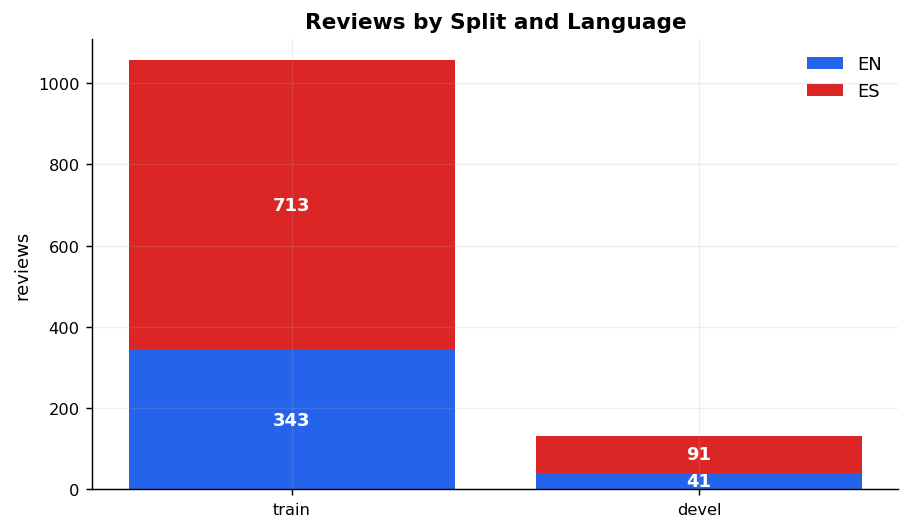

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
split_names = list(splits.keys())
bottom = np.zeros(len(split_names))
for language in ["en", "es"]:
    values = [Counter(ex["language"] for ex in splits[split]).get(language, 0) for split in split_names]
    bars = ax.bar(split_names, values, bottom=bottom, label=language.upper(), color=COLORS[language])
    for bar, value, base in zip(bars, values, bottom):
        ax.text(bar.get_x() + bar.get_width() / 2, base + value / 2, str(value), ha="center", va="center", color="white", fontweight="bold")
    bottom += values
ax.set_title("Reviews by Split and Language")
ax.set_ylabel("reviews")
ax.legend(loc="upper right")
plt.show()

## Number of Gold Labels per Review

This plot is useful for detecting over-prediction. A zero-shot model that returns many more labels per review than the gold distribution is likely losing precision.

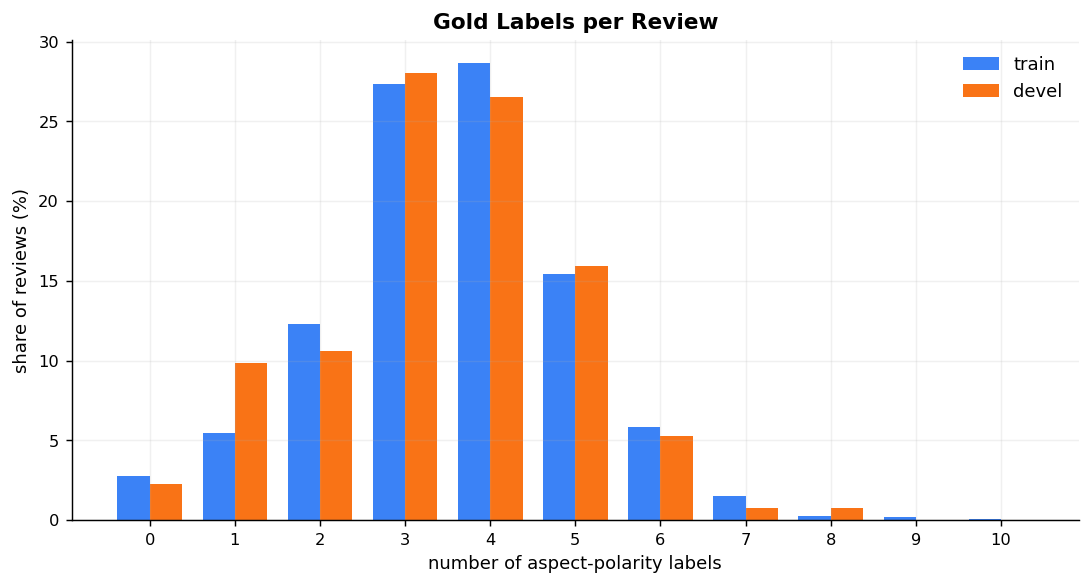

In [6]:
max_labels = max(len(ex["gold"]) for _, ex in all_examples)
x = np.arange(max_labels + 1)
bar_width = 0.38
fig, ax = plt.subplots(figsize=(10, 4.8))
for i, (split, data) in enumerate(splits.items()):
    counts = Counter(len(ex["gold"]) for ex in data)
    values = [pct(counts.get(k, 0), len(data)) for k in x]
    ax.bar(x + (i - 0.5) * bar_width, values, width=bar_width, label=split, color=COLORS[split])
ax.set_title("Gold Labels per Review")
ax.set_xlabel("number of aspect-polarity labels")
ax.set_ylabel("share of reviews (%)")
ax.set_xticks(x)
ax.legend()
plt.show()

## Aspect Imbalance

The task is not balanced. `restaurant_general`, `food_quality`, and `service` dominate. Baselines exploiting this imbalance are strong and must be beaten.

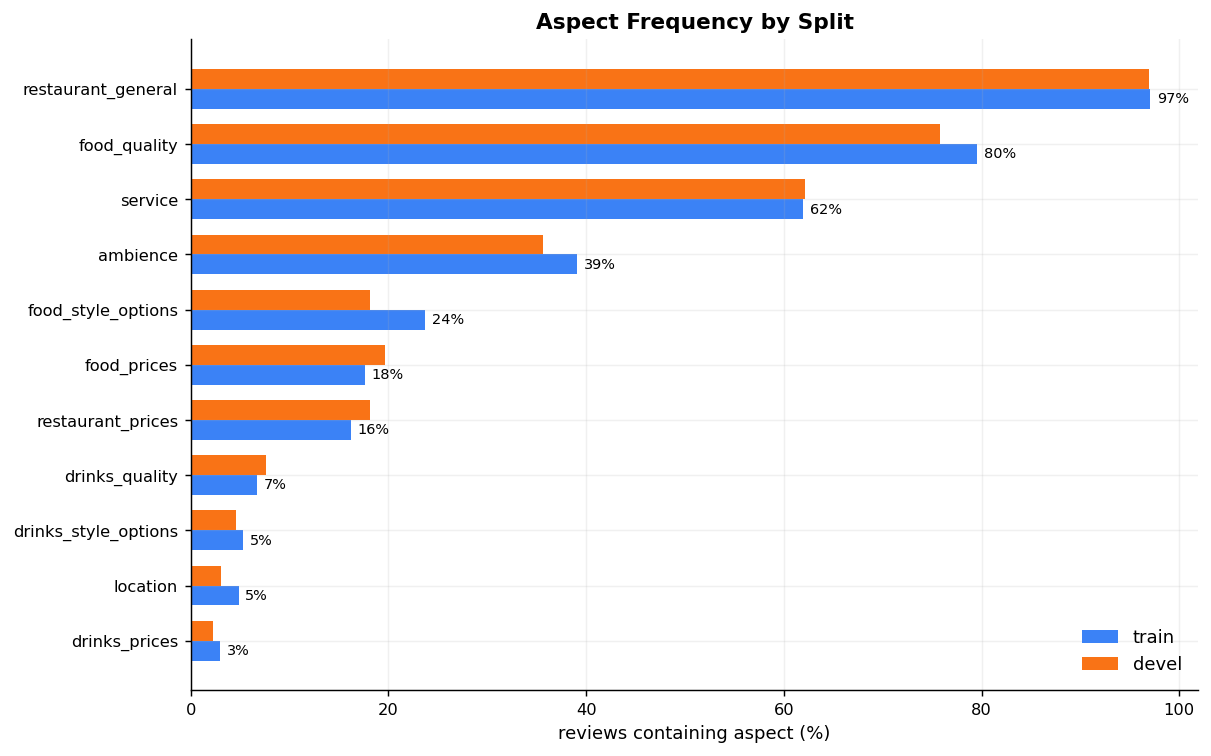

In [7]:
train_aspects = aspect_counter(train)
devel_aspects = aspect_counter(devel)
ordered_aspects = [aspect for aspect, _ in train_aspects.most_common()]

y = np.arange(len(ordered_aspects))
fig, ax = plt.subplots(figsize=(10, 6.5))
train_pct = [pct(train_aspects[a], len(train)) for a in ordered_aspects]
devel_pct = [pct(devel_aspects[a], len(devel)) for a in ordered_aspects]
ax.barh(y + 0.18, train_pct, height=0.36, label="train", color=COLORS["train"])
ax.barh(y - 0.18, devel_pct, height=0.36, label="devel", color=COLORS["devel"])
ax.set_yticks(y)
ax.set_yticklabels(ordered_aspects)
ax.invert_yaxis()
ax.set_xlabel("reviews containing aspect (%)")
ax.set_title("Aspect Frequency by Split")
ax.legend()
for yi, value in enumerate(train_pct):
    ax.text(value + 0.7, yi + 0.18, f"{value:.0f}%", va="center", fontsize=8)
plt.show()

## Polarity Imbalance

Most labels are positive. This makes majority-polarity baselines deceptively strong and makes `neutral`/`conflict` the labels where prompting, retrieval, and synthetic data can add value.

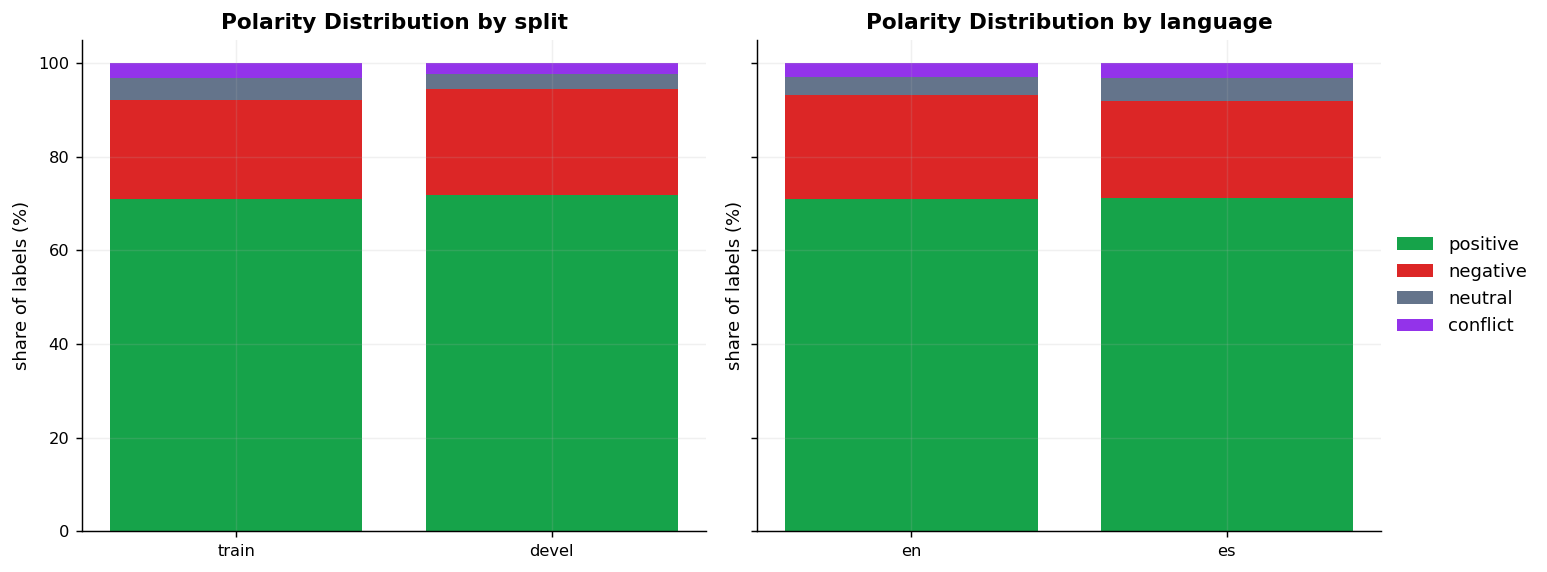

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, grouping_name in zip(axes, ["split", "language"]):
    if grouping_name == "split":
        groups = splits
    else:
        groups = {
            "en": [ex for _, ex in all_examples if ex["language"] == "en"],
            "es": [ex for _, ex in all_examples if ex["language"] == "es"],
        }
    x_names = list(groups.keys())
    bottom = np.zeros(len(x_names))
    for polarity in POLARITIES:
        values = []
        for name in x_names:
            counts = polarity_counter(groups[name])
            total = sum(counts.values())
            values.append(pct(counts.get(polarity, 0), total))
        ax.bar(x_names, values, bottom=bottom, label=polarity, color=COLORS[polarity])
        bottom += values
    ax.set_title(f"Polarity Distribution by {grouping_name}")
    ax.set_ylabel("share of labels (%)")
axes[1].legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

## Aspect-Polarity Matrix

This highlights rare combinations. Those combinations should be covered by cherry-picked few-shot examples and targeted augmentation.

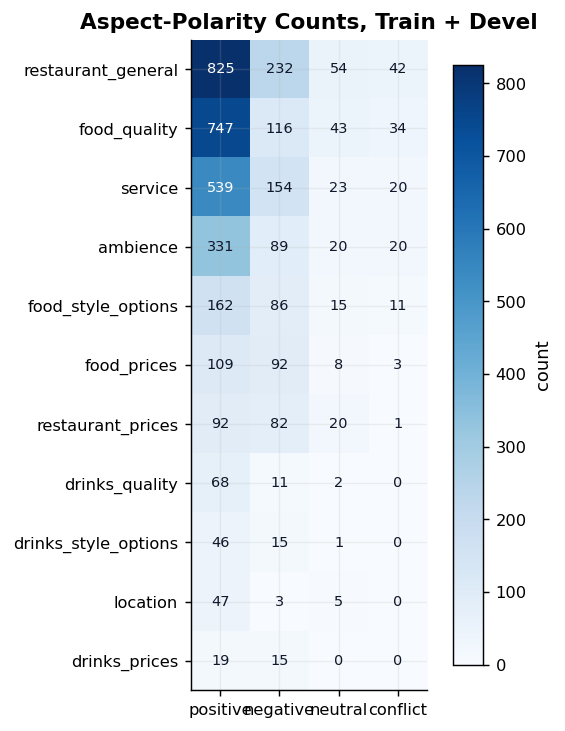

In [9]:
combined_pairs = pair_counter([ex for _, ex in all_examples])
matrix = np.array([[combined_pairs.get((aspect, polarity), 0) for polarity in POLARITIES] for aspect in ordered_aspects])

fig, ax = plt.subplots(figsize=(8.5, 6.5))
im = ax.imshow(matrix, cmap="Blues")
ax.set_xticks(np.arange(len(POLARITIES)))
ax.set_xticklabels(POLARITIES)
ax.set_yticks(np.arange(len(ordered_aspects)))
ax.set_yticklabels(ordered_aspects)
ax.set_title("Aspect-Polarity Counts, Train + Devel")
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        value = int(matrix[i, j])
        ax.text(j, i, str(value), ha="center", va="center", fontsize=8, color="white" if value > matrix.max() * 0.45 else "#0f172a")
fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03, label="count")
plt.show()

In [10]:
rare_pairs = sorted(combined_pairs.items(), key=lambda item: item[1])[:12]
print_markdown_table(["aspect", "polarity", "count"], [[a, p, c] for (a, p), c in rare_pairs])

| aspect | polarity | count |
| --- | --- | --- |
| drinks_style_options | neutral | 1 |
| restaurant_prices | conflict | 1 |
| drinks_quality | neutral | 2 |
| food_prices | conflict | 3 |
| location | negative | 3 |
| location | neutral | 5 |
| food_prices | neutral | 8 |
| food_style_options | conflict | 11 |
| drinks_quality | negative | 11 |
| food_style_options | neutral | 15 |
| drinks_style_options | negative | 15 |
| drinks_prices | negative | 15 |


## Aspect Co-occurrence

Co-occurrence matters for synthetic data. Random aspect combinations can create unrealistic reviews; sampling from observed co-occurrence patterns is safer, then deliberately oversampling rare labels.

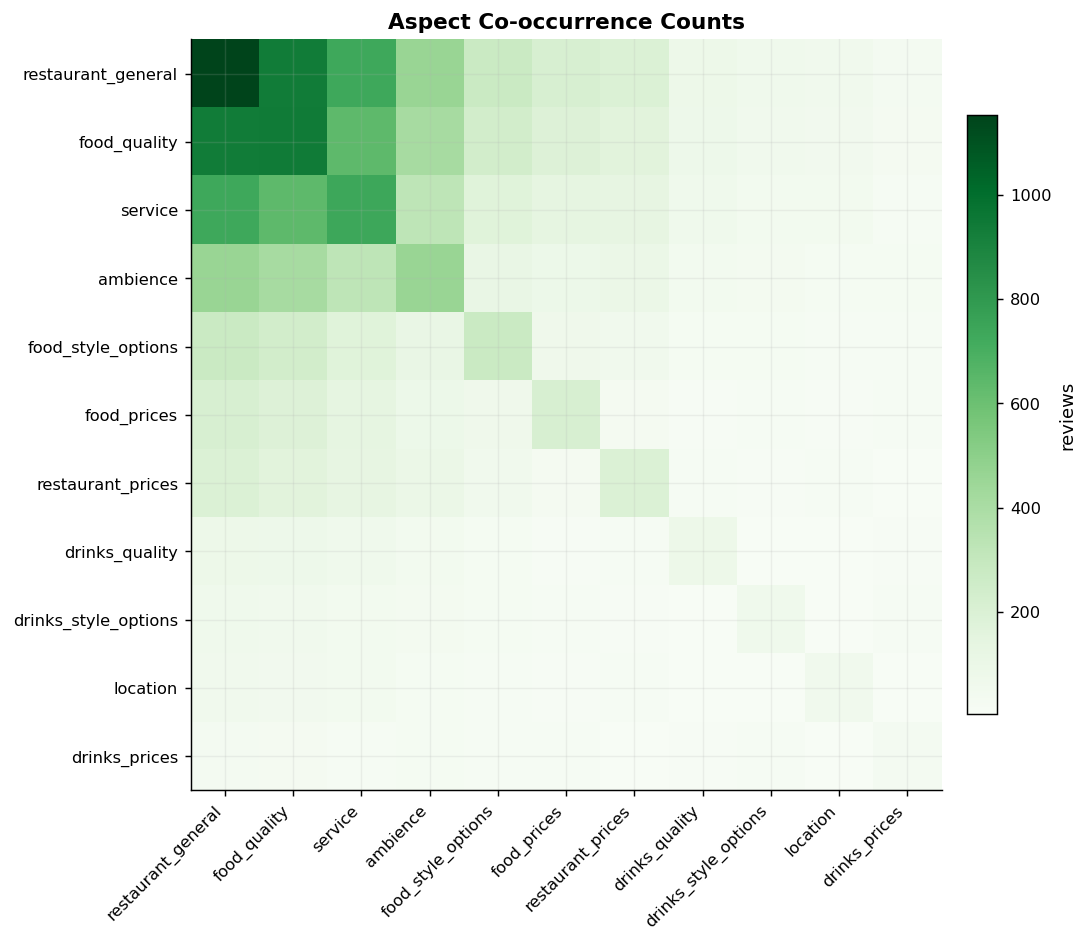

In [11]:
cooc = np.zeros((len(ordered_aspects), len(ordered_aspects)), dtype=int)
index = {aspect: i for i, aspect in enumerate(ordered_aspects)}
for _, ex in all_examples:
    present = list(ex["gold"].keys())
    for a in present:
        for b in present:
            cooc[index[a], index[b]] += 1

fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(cooc, cmap="Greens")
ax.set_xticks(np.arange(len(ordered_aspects)))
ax.set_xticklabels(ordered_aspects, rotation=45, ha="right")
ax.set_yticks(np.arange(len(ordered_aspects)))
ax.set_yticklabels(ordered_aspects)
ax.set_title("Aspect Co-occurrence Counts")
fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03, label="reviews")
plt.show()

## Lengths and Label Density

This is a proxy for prompt length. The actual token-budget section below should be used once the Qwen tokenizer is available.

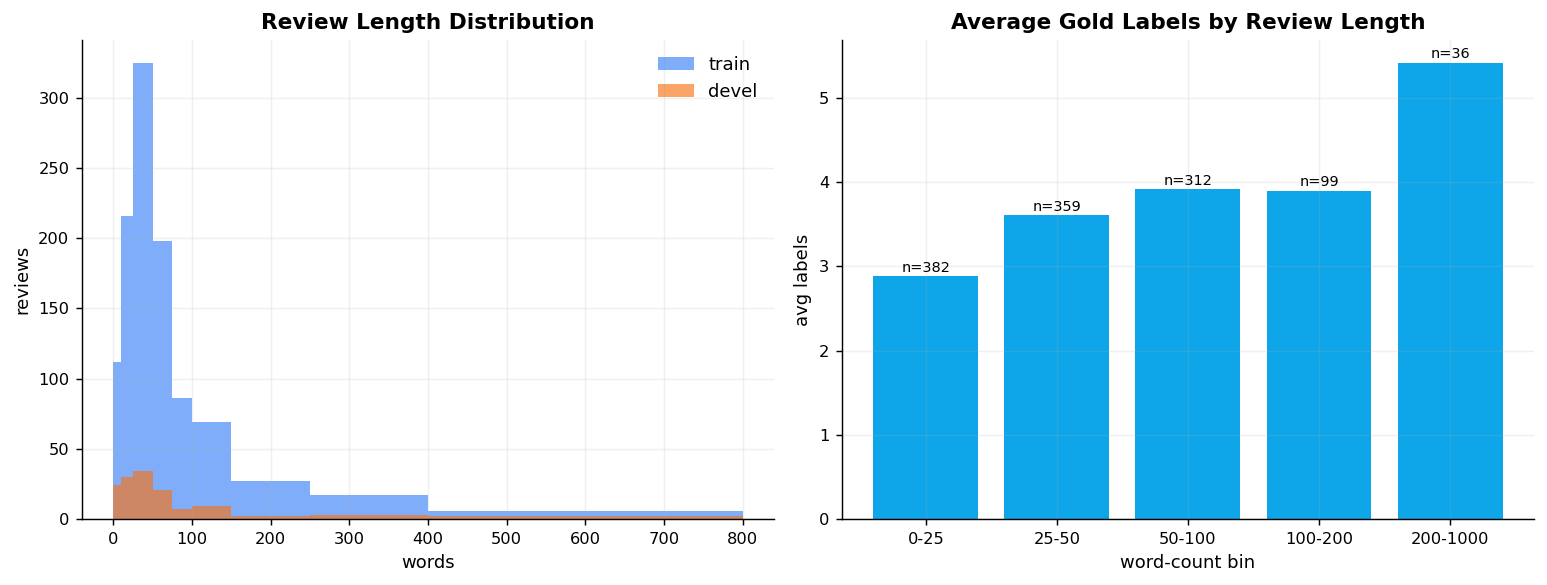

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for split, data in splits.items():
    lengths = [len(ex["text"].split()) for ex in data]
    axes[0].hist(lengths, bins=[0, 10, 25, 50, 75, 100, 150, 250, 400, 800], alpha=0.65, label=split, color=COLORS[split])
axes[0].set_title("Review Length Distribution")
axes[0].set_xlabel("words")
axes[0].set_ylabel("reviews")
axes[0].legend()

bins = [(0, 25), (25, 50), (50, 100), (100, 200), (200, 1000)]
labels = []
means = []
counts = []
for left, right in bins:
    selected = [len(ex["gold"]) for _, ex in all_examples if left <= len(ex["text"].split()) < right]
    labels.append(f"{left}-{right}")
    means.append(np.mean(selected) if selected else 0)
    counts.append(len(selected))
bars = axes[1].bar(labels, means, color="#0EA5E9")
axes[1].set_title("Average Gold Labels by Review Length")
axes[1].set_xlabel("word-count bin")
axes[1].set_ylabel("avg labels")
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05, f"n={count}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## Baselines

These are not optional. A model result only becomes interesting if it beats simple label-frequency baselines.

In [13]:
def majority_polarity_by_aspect(data):
    by_aspect = defaultdict(Counter)
    for ex in data:
        for aspect, polarity in ex["gold"].items():
            by_aspect[aspect][polarity] += 1
    return {aspect: counts.most_common(1)[0][0] for aspect, counts in by_aspect.items()}

majority_polarity = majority_polarity_by_aspect(train)
top_aspects = [aspect for aspect, _ in train_aspects.most_common()]

def constant_prediction(aspects, polarity="positive"):
    return {aspect: polarity for aspect in aspects}

def majority_prediction(aspects):
    return {aspect: majority_polarity[aspect] for aspect in aspects}

baseline_rows = []
baseline_predictions = {
    "empty": [{} for _ in devel],
    "restaurant_general_positive": [constant_prediction(["restaurant_general"]) for _ in devel],
}
for k in [1, 2, 3, 4, 5, 8, 11]:
    baseline_predictions[f"top{k}_positive"] = [constant_prediction(top_aspects[:k]) for _ in devel]
    baseline_predictions[f"top{k}_majority"] = [majority_prediction(top_aspects[:k]) for _ in devel]

# Diagnostic upper bound: assumes perfect aspect detection, only tests majority polarity.
baseline_predictions["oracle_aspects_majority_polarity"] = [
    {aspect: majority_polarity.get(aspect, "positive") for aspect in ex["gold"]}
    for ex in devel
]

for name, preds in baseline_predictions.items():
    score = evaluate_predictions(devel, preds)
    baseline_rows.append([name, f"{score['P_macro']:.1f}", f"{score['R_macro']:.1f}", f"{score['F1_macro']:.1f}", f"{score['F1_micro']:.1f}"])

baseline_rows = sorted(baseline_rows, key=lambda row: float(row[3]), reverse=True)
print_markdown_table(["baseline", "P macro", "R macro", "F1 macro", "F1 micro"], baseline_rows)

| baseline | P macro | R macro | F1 macro | F1 micro |
| --- | --- | --- | --- | --- |
| oracle_aspects_majority_polarity | 72.6 | 72.6 | 72.6 | 71.8 |
| top3_positive | 60.4 | 56.8 | 55.6 | 56.2 |
| top3_majority | 60.4 | 56.8 | 55.6 | 56.2 |
| top4_positive | 51.9 | 63.4 | 54.5 | 55.8 |
| top4_majority | 51.9 | 63.4 | 54.5 | 55.8 |
| top2_positive | 67.0 | 44.3 | 50.4 | 49.3 |
| top2_majority | 67.0 | 44.3 | 50.4 | 49.3 |
| top5_positive | 43.5 | 65.8 | 50.2 | 51.5 |
| top5_majority | 43.5 | 65.8 | 50.2 | 51.5 |
| top8_positive | 29.8 | 70.7 | 40.5 | 41.7 |
| top8_majority | 29.8 | 70.7 | 40.5 | 41.7 |
| restaurant_general_positive | 72.0 | 27.2 | 36.9 | 32.4 |
| top1_positive | 72.0 | 27.2 | 36.9 | 32.4 |
| top1_majority | 72.0 | 27.2 | 36.9 | 32.4 |
| top11_positive | 22.5 | 72.6 | 33.3 | 34.2 |
| top11_majority | 22.5 | 72.6 | 33.3 | 34.2 |
| empty | 0.0 | 0.0 | 0.0 | 0.0 |


**Baseline conclusions**

- `top3_positive` / `top3_majority` is already a strong baseline because the dataset is dominated by `restaurant_general`, `food_quality`, and `service`.
- A zero-shot model below this baseline is not useful yet, even if individual predictions look plausible.
- The `oracle_aspects_majority_polarity` row is not a real baseline; it estimates how much F1 is left if aspect detection is solved but polarity is still majority-based.

## Token Budget for `max_new_tokens`

For non-thinking ABSA, the expected final answer is a tiny JSON object. `max_new_tokens=512` is safe but probably wasteful. The cell below uses the Qwen tokenizer if the model is downloaded.

For thinking mode, `max_new_tokens` includes both the hidden/visible reasoning segment and the final JSON. That means a thinking run with `max_new_tokens=512` may be much more constrained than a non-thinking run with the same value.

In [14]:
def percentile(values, q):
    return float(np.percentile(np.array(values), q)) if values else 0.0

answer_jsons = [json.dumps(ex["gold"], ensure_ascii=False) for ex in train + devel]
answer_chars = [len(x) for x in answer_jsons]
print("Gold JSON character length:")
print(f"  p50={percentile(answer_chars, 50):.0f}, p90={percentile(answer_chars, 90):.0f}, p95={percentile(answer_chars, 95):.0f}, p99={percentile(answer_chars, 99):.0f}, max={max(answer_chars)}")

try:
    from transformers import AutoTokenizer
    sys.path.insert(0, str(ABSA_DIR / "bin"))
    from common import get_prompts, prepare_messages

    tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
    prompts = get_prompts(PROMPT_FILE)

    prompt_tokens = []
    answer_tokens = []
    for ex in train + devel:
        messages = prepare_messages(prompts, ex)
        prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)
        prompt_tokens.append(len(tokenizer(prompt_text)["input_ids"]))
        answer_tokens.append(len(tokenizer(json.dumps(ex["gold"], ensure_ascii=False))["input_ids"]))

    print("\nQwen token lengths:")
    print(f"  prompt tokens: p50={percentile(prompt_tokens, 50):.0f}, p95={percentile(prompt_tokens, 95):.0f}, p99={percentile(prompt_tokens, 99):.0f}, max={max(prompt_tokens)}")
    print(f"  gold JSON answer tokens: p50={percentile(answer_tokens, 50):.0f}, p95={percentile(answer_tokens, 95):.0f}, p99={percentile(answer_tokens, 99):.0f}, max={max(answer_tokens)}")

    lean_candidate = int(max(128, math.ceil(percentile(answer_tokens, 99) + 64)))
    conservative_candidate = int(max(256, math.ceil(max(answer_tokens) + 96)))
    print("\nNon-thinking max_new_tokens candidates from the observed gold JSON budget:")
    print(f"  lean candidate={lean_candidate}")
    print(f"  conservative candidate={conservative_candidate}")
    print("  Keep 512 as a debugging safety budget until model outputs are measured.")
except Exception as exc:
    print("Tokenizer-based budget skipped:", repr(exc))
    print("Run this cell on Vast after downloading ABSA/model. Until then, keep 512 only as a debugging safety budget.")


Gold JSON character length:
  p50=109, p90=150, p95=172, p99=204, max=294



Qwen token lengths:
  prompt tokens: p50=524, p95=670, p99=924, max=1586
  gold JSON answer tokens: p50=27, p95=43, p99=52, max=74

Non-thinking max_new_tokens candidates from the observed gold JSON budget:
  lean candidate=128
  conservative candidate=256
  Keep 512 as a debugging safety budget until model outputs are measured.


## Thinking Output Budget Check

Run zero-shot thinking with `--keep-raw`, then point `thinking_output` to that file. This estimates how many generated tokens were spent in `<think>...</think>` versus the final JSON.

This is the empirical check we need before deciding a thinking `max_new_tokens` budget.

In [15]:
thinking_output = OUTPUT_DIR / "test_zs_thinking.json"  # change this to a real thinking output file

if not thinking_output.exists():
    print("No thinking output found yet:", thinking_output)
    print("Example command from ABSA/:")
    print("  python3 bin/zeroshot.py --thinking --limit 20 --keep-raw --max-new-tokens 1024 --output outputs/test_zs_thinking.json")
else:
    try:
        from transformers import AutoTokenizer
        tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
        rows = json.load(open(thinking_output, encoding="utf-8"))
        think_lengths = []
        final_lengths = []
        total_lengths = []
        for row in rows:
            raw = row.get("raw_generation", "")
            if "</think>" in raw:
                think_text, final_text = raw.split("</think>", 1)
            else:
                think_text, final_text = "", raw
            think_lengths.append(len(tokenizer(think_text)["input_ids"]))
            final_lengths.append(len(tokenizer(final_text)["input_ids"]))
            total_lengths.append(len(tokenizer(raw)["input_ids"]))
        print("Thinking output token lengths:")
        for name, values in [("think", think_lengths), ("final", final_lengths), ("total", total_lengths)]:
            print(f"  {name:5s}: p50={percentile(values, 50):.0f}, p90={percentile(values, 90):.0f}, p95={percentile(values, 95):.0f}, max={max(values)}")
    except Exception as exc:
        print("Could not analyze thinking output:", repr(exc))

No thinking output found yet: /workspace/Aspect-Based-Sentiment-Analysis-with-LLMs/distribucio-codi-i-dades-12-03-26/ABSA/outputs/test_zs_thinking.json
Example command from ABSA/:
  python3 bin/zeroshot.py --thinking --limit 20 --keep-raw --max-new-tokens 1024 --output outputs/test_zs_thinking.json


## Decisions from This Analysis

1. **Baselines first.** Every zero-shot, few-shot, and fine-tuned model must beat `top3_positive` / `top3_majority` before we claim progress.
2. **Avoid over-prediction.** The target distribution is centered around 3-4 labels per review. Prompting should discourage listing every plausible aspect.
3. **Do not trust accuracy on positives alone.** Positive labels dominate; inspect `negative`, `neutral`, and `conflict` separately when comparing strong runs.
4. **Few-shot retrieval should be label-aware.** Pure similarity may keep selecting common positive examples. Add diversity or coverage of rare aspect-polarity pairs.
5. **Synthetic data should not sample arbitrary aspect sets uniformly.** Use observed co-occurrence patterns, then oversample rare polarities/pairs intentionally.
6. **Do not finalize `max_new_tokens` before measuring tokens.** Use 512 only as a debugging safety budget; choose the actual non-thinking budget after the tokenizer/output cells above run on Vast.
7. **For thinking, measure raw generations.** The reasoning segment counts against `max_new_tokens`; run a small `--thinking --keep-raw` sample and inspect token usage before full devel runs.

## Prompt iteration notes

For the next zero-shot prompt, the evidence suggests three changes:

- Treat the 3-4 labels-per-review figure as an average, not a cap.
- Prioritize the common aspects first: `restaurant_general`, `food_quality`, and `service`.
- Map strong lexical cues directly to aspects instead of waiting for an exact keyword match, especially for food, service, ambience, and prices.

This should recover recall without reopening the neutral-as-absence failure mode.